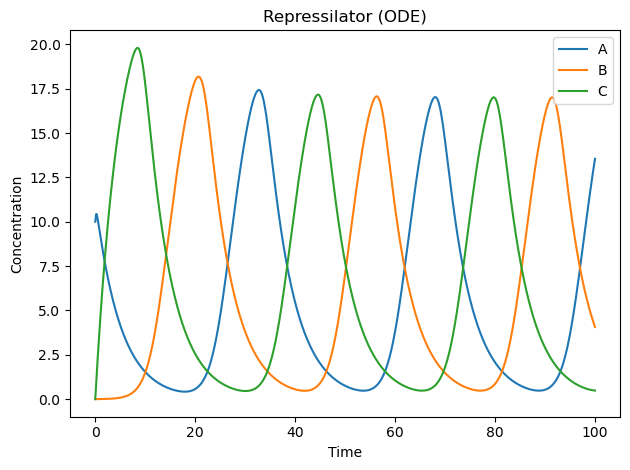

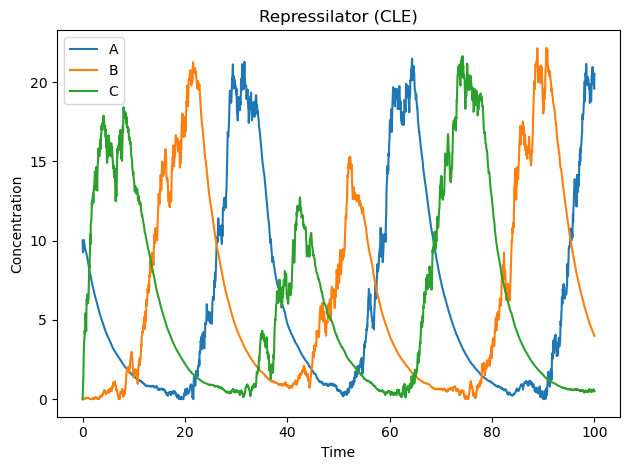

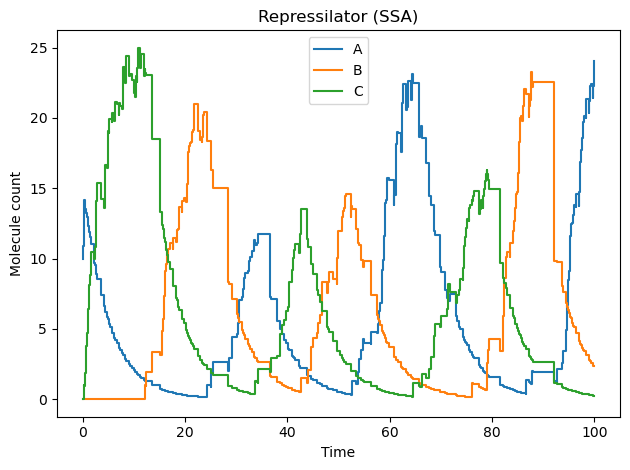

In [30]:
import repressilator as rep
from scipy.signal import correlate, correlation_lags
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d

(t_ode, y_ode) = rep.run_ode_demo()
(t_cle, y_cle) = rep.run_cle_demo()
(t_ssa, y_ssa) = rep.run_ssa_demo()

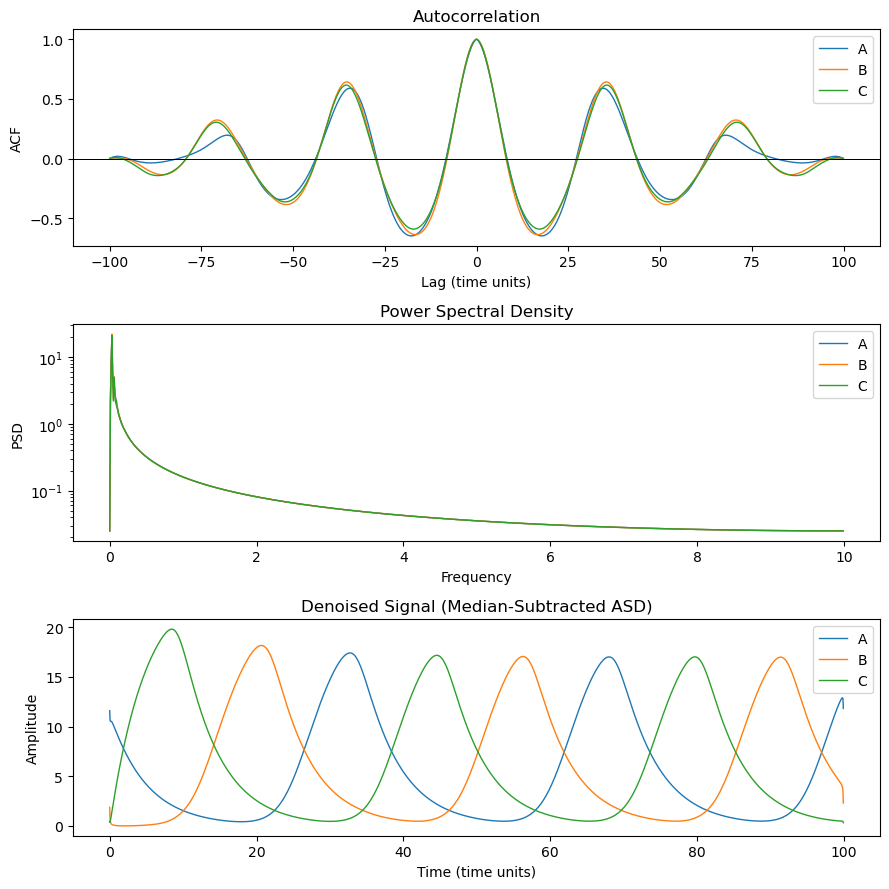

Dominant frequency for A: 0.0300 (period ~ 33.33 time units)
Dominant frequency for B: 0.0300 (period ~ 33.33 time units)
Dominant frequency for C: 0.0300 (period ~ 33.33 time units)


In [31]:
plt.rcParams['image.interpolation'] = 'none'

dt = np.median(np.diff(t_ode))
t_uniform_ode = np.arange(t_ode[0], t_ode[-1], dt)
y_uniform_ode = np.column_stack([interp1d(t_ode, y_ode[i, :], kind="linear")(t_uniform_ode) for i in range(y_ode.shape[0])])
t_uniform = t_uniform_ode
y_uniform = y_uniform_ode
labels = ["A", "B", "C"]
 
# ── Autocorrelation and PSD per state variable ────────────────────────────────
lags = correlation_lags(len(t_uniform), len(t_uniform), mode="full")
lags_time = lags * dt
mid = len(lags) // 2
 
acf_all = []
psd_all = []
 
for i in range(y_uniform.shape[1]):
    yc = y_uniform[:, i] - y_uniform[:, i].mean()
    acf = correlate(yc, yc, mode="full")
    acf /= acf[mid]
    acf_all.append(acf)
 
    psd = np.abs(np.fft.rfft(acf[mid:])) * dt
    psd_all.append(psd)
 
freqs_ode = np.fft.rfftfreq(len(t_uniform), d=dt)
freqs = freqs_ode
 
acf_all = np.column_stack(acf_all)   # shape (n_lags, 3)
psd_all = np.column_stack(psd_all)   # shape (n_freqs, 3)

# ── Amplitude Spectral Density with denoising ────────────────────────────────
asd_original_ode = []
asd_processed_ode = []
clean_signal_ode = []

for i in range(y_uniform.shape[1]):
    # FFT of the original signal
    fft_vals = np.fft.rfft(y_uniform[:, i])
    asd = np.abs(fft_vals)
    asd_original_ode.append(asd)  # Store original ASD
    
    # Find median of ASD and subtract to remove noise
    asd_median = np.median(asd)
    asd_denoised = asd - asd_median
    asd_processed_ode.append(asd_denoised)  # Store processed ASD
    
    # Preserve phase information and reconstruct signal
    phase = np.angle(fft_vals)
    fft_denoised = asd_denoised * np.exp(1j * phase)
    clean_signal = np.fft.irfft(fft_denoised, n=len(y_uniform[:, i]))
    clean_signal_ode.append(clean_signal)

asd_original_ode = np.column_stack(asd_original_ode)   # shape (n_freqs, 3)
asd_processed_ode = np.column_stack(asd_processed_ode) # shape (n_freqs, 3)
clean_signal_ode = np.column_stack(clean_signal_ode)   # shape (n_time, 3)
 
max_lag = int(len(lags_time))   # show first 20 % of lags
 
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(9, 9), tight_layout=True)
 
for i in range(3):
    ax1.plot(lags_time[:max_lag], acf_all[:max_lag, i], lw=1.0, label=labels[i])
    ax1.axhline(0, color="k", lw=0.6)
    ax1.set_xlabel("Lag (time units)")
    ax1.set_ylabel("ACF")
    ax1.set_title("Autocorrelation")
    ax1.legend()
 
for i in range(3):
    ax2.semilogy(freqs, psd_all[:, i], lw=1.0, label=labels[i])
    ax2.set_xlabel("Frequency")
    ax2.set_ylabel("PSD")
    ax2.set_title("Power Spectral Density")
    ax2.legend()

for i in range(3):
    ax3.plot(t_uniform, clean_signal_ode[:, i], lw=1.0, label=labels[i])
    ax3.set_xlabel("Time (time units)")
    ax3.set_ylabel("Amplitude")
    ax3.set_title("Denoised Signal (Median-Subtracted ASD)")
    ax3.legend()

plt.show()

dominant_freqA = freqs[np.argmax(psd_all[:, 0])]
print(f"Dominant frequency for A: {dominant_freqA:.4f} (period ~ {1/dominant_freqA:.2f} time units)")

dominant_freqB = freqs[np.argmax(psd_all[:, 1])]
print(f"Dominant frequency for B: {dominant_freqB:.4f} (period ~ {1/dominant_freqB:.2f} time units)")


dominant_freqC = freqs[np.argmax(psd_all[:, 2])]
print(f"Dominant frequency for C: {dominant_freqC:.4f} (period ~ {1/dominant_freqC:.2f} time units)")

In [ ]:
plt.rcParams['image.interpolation'] = 'none'

dt = np.median(np.diff(t_cle))
t_uniform_cle = np.arange(t_cle[0], t_cle[-1], dt)
y_uniform_cle = np.column_stack([interp1d(t_cle, y_cle[i, :], kind="linear")(t_uniform_cle) for i in range(y_cle.shape[0])])
t_uniform = t_uniform_cle
y_uniform = y_uniform_cle
labels = ["A", "B", "C"]
 
# ── Autocorrelation and PSD per state variable ────────────────────────────────
lags = correlation_lags(len(t_uniform), len(t_uniform), mode="full")
lags_time = lags * dt
mid = len(lags) // 2
 
acf_all = []
psd_all = []
 
for i in range(y_uniform.shape[1]):
    yc = y_uniform[:, i] - y_uniform[:, i].mean()
    acf = correlate(yc, yc, mode="full")
    acf /= acf[mid]
    acf_all.append(acf)
 
    psd = np.abs(np.fft.rfft(acf[mid:])) * dt
    psd_all.append(psd)
 
freqs_cle = np.fft.rfftfreq(len(t_uniform), d=dt)
freqs = freqs_cle
 
acf_all = np.column_stack(acf_all)   # shape (n_lags, 3)
psd_all = np.column_stack(psd_all)   # shape (n_freqs, 3)

# ── Amplitude Spectral Density with denoising and low-pass filter ────────────────────────────────
asd_original_cle = []
asd_processed_cle = []
clean_signal_cle = []

# Ideal low-pass filter: cutoff at 10X the nominal max frequency of 0.03
cutoff_freq = 5 * 0.03
ideal_lp_filter = np.where(freqs <= cutoff_freq, 1, 0)

for i in range(y_uniform.shape[1]):
    # FFT of the original signal
    fft_vals = np.fft.rfft(y_uniform[:, i])
    asd = np.abs(fft_vals)
    asd_original_cle.append(asd)  # Store original ASD
    
    # Find median of ASD and subtract to remove noise
    asd_median = np.median(asd)
    asd_denoised = asd - asd_median
    
    # Apply ideal low-pass filter
    asd_filtered = asd_denoised * ideal_lp_filter
    asd_processed_cle.append(asd_filtered)  # Store processed ASD (after denoising and filtering)
    
    # Preserve phase information and reconstruct signal
    phase = np.angle(fft_vals)
    fft_denoised = asd_filtered * np.exp(1j * phase)
    clean_signal = np.fft.irfft(fft_denoised, n=len(y_uniform[:, i]))
    clean_signal_cle.append(clean_signal)

asd_original_cle = np.column_stack(asd_original_cle)   # shape (n_freqs, 3)
asd_processed_cle = np.column_stack(asd_processed_cle) # shape (n_freqs, 3)
clean_signal_cle = np.column_stack(clean_signal_cle)   # shape (n_time, 3)
 
max_lag = int(len(lags_time))   # show first 20 % of lags
 
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(9, 9), tight_layout=True)
 
for i in range(3):
    ax1.plot(lags_time[:max_lag], acf_all[:max_lag, i], lw=1.0, label=labels[i])
    ax1.axhline(0, color="k", lw=0.6)
    ax1.set_xlabel("Lag (time units)")
    ax1.set_ylabel("ACF")
    ax1.set_title("Autocorrelation (CLE)")
    ax1.legend()
 
for i in range(3):
    ax2.semilogy(freqs, psd_all[:, i], lw=1.0, label=labels[i])
    ax2.set_xlabel("Frequency")
    ax2.set_ylabel("PSD")
    ax2.set_title("Power Spectral Density (CLE)")
    ax2.legend()

for i in range(3):
    ax3.plot(t_uniform, clean_signal_cle[:, i], lw=1.0, label=labels[i])
    ax3.set_xlabel("Time (time units)")
    ax3.set_ylabel("Amplitude")
    ax3.set_title("Denoised Signal with Low-Pass Filter (CLE)")
    ax3.legend()

plt.show()

dominant_freqA = freqs[np.argmax(psd_all[:, 0])]
print(f"Dominant frequency for A: {dominant_freqA:.4f} (period ~ {1/dominant_freqA:.2f} time units)")

dominant_freqB = freqs[np.argmax(psd_all[:, 1])]
print(f"Dominant frequency for B: {dominant_freqB:.4f} (period ~ {1/dominant_freqB:.2f} time units)")


dominant_freqC = freqs[np.argmax(psd_all[:, 2])]
print(f"Dominant frequency for C: {dominant_freqC:.4f} (period ~ {1/dominant_freqC:.2f} time units)")

SyntaxError: invalid syntax (2156973286.py, line 101)

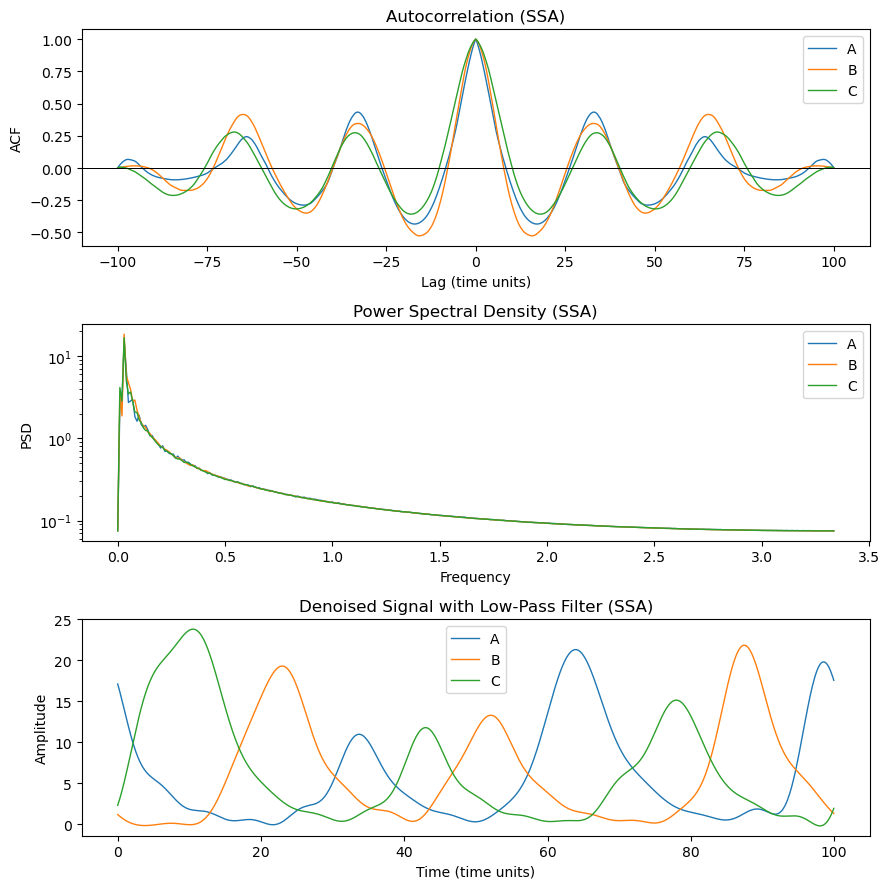

Dominant frequency for A: 0.0300 (period ~ 33.37 time units)
Dominant frequency for B: 0.0300 (period ~ 33.37 time units)
Dominant frequency for C: 0.0300 (period ~ 33.37 time units)


In [ ]:
plt.rcParams['image.interpolation'] = 'none'

dt = np.median(np.diff(t_ssa))
t_uniform_ssa = np.arange(t_ssa[0], t_ssa[-1], dt)
y_uniform_ssa = np.column_stack([interp1d(t_ssa, y_ssa[i, :], kind="linear")(t_uniform_ssa) for i in range(y_ssa.shape[0])])
t_uniform = t_uniform_ssa
y_uniform = y_uniform_ssa
labels = ["A", "B", "C"]
 
# ── Autocorrelation and PSD per state variable ────────────────────────────────
lags = correlation_lags(len(t_uniform), len(t_uniform), mode="full")
lags_time = lags * dt
mid = len(lags) // 2
 
acf_all = []
psd_all = []
 
for i in range(y_uniform.shape[1]):
    yc = y_uniform[:, i] - y_uniform[:, i].mean()
    acf = correlate(yc, yc, mode="full")
    acf /= acf[mid]
    acf_all.append(acf)
 
    psd = np.abs(np.fft.rfft(acf[mid:])) * dt
    psd_all.append(psd)
 
freqs_ssa = np.fft.rfftfreq(len(t_uniform), d=dt)
freqs = freqs_ssa
 
acf_all = np.column_stack(acf_all)   # shape (n_lags, 3)
psd_all = np.column_stack(psd_all)   # shape (n_freqs, 3)

# ── Amplitude Spectral Density with denoising and low-pass filter ────────────────────────────────
asd_original_ssa = []
asd_processed_ssa = []
clean_signal_ssa = []

# Ideal low-pass filter: cutoff at 10X the nominal max frequency of 0.03
cutoff_freq = 5 * 0.03
ideal_lp_filter = np.where(freqs <= cutoff_freq, 1, 0)

for i in range(y_uniform.shape[1]):
    # FFT of the original signal
    fft_vals = np.fft.rfft(y_uniform[:, i])
    asd = np.abs(fft_vals)
    asd_original_ssa.append(asd)  # Store original ASD
    
    # Find median of ASD and subtract to remove noise
    asd_median = np.median(asd)
    asd_denoised = asd - asd_median
    
    # Apply ideal low-pass filter
    asd_filtered = asd_denoised * ideal_lp_filter
    asd_processed_ssa.append(asd_filtered)  # Store processed ASD (after denoising and filtering)
    
    # Preserve phase information and reconstruct signal
    phase = np.angle(fft_vals)
    fft_denoised = asd_filtered * np.exp(1j * phase)
    clean_signal = np.fft.irfft(fft_denoised, n=len(y_uniform[:, i]))
    clean_signal_ssa.append(clean_signal)

asd_original_ssa = np.column_stack(asd_original_ssa)   # shape (n_freqs, 3)
asd_processed_ssa = np.column_stack(asd_processed_ssa) # shape (n_freqs, 3)
clean_signal_ssa = np.column_stack(clean_signal_ssa)   # shape (n_time, 3)
 
max_lag = int(len(lags_time))   # show first 20 % of lags
 
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(9, 9), tight_layout=True)
 
for i in range(3):
    ax1.plot(lags_time[:max_lag], acf_all[:max_lag, i], lw=1.0, label=labels[i])
    ax1.axhline(0, color="k", lw=0.6)
    ax1.set_xlabel("Lag (time units)")
    ax1.set_ylabel("ACF")
    ax1.set_title("Autocorrelation (SSA)")
    ax1.legend()
 
for i in range(3):
    ax2.semilogy(freqs, psd_all[:, i], lw=1.0, label=labels[i])
    ax2.set_xlabel("Frequency")
    ax2.set_ylabel("PSD")
    ax2.set_title("Power Spectral Density (SSA)")
    ax2.legend()

for i in range(3):
    ax3.plot(t_uniform, clean_signal_ssa[:, i], lw=1.0, label=labels[i])
    ax3.set_xlabel("Time (time units)")
    ax3.set_ylabel("Amplitude")
    ax3.set_title("Denoised Signal with Low-Pass Filter (SSA)")
    ax3.legend()

plt.show()

dominant_freqA = freqs[np.argmax(psd_all[:, 0])]
print(f"Dominant frequency for A: {dominant_freqA:.4f} (period ~ {1/dominant_freqA:.2f} time units)")

dominant_freqB = freqs[np.argmax(psd_all[:, 1])]
print(f"Dominant frequency for B: {dominant_freqB:.4f} (period ~ {1/dominant_freqB:.2f} time units)")


dominant_freqC = freqs[np.argmax(psd_all[:, 2])]print(f"Dominant frequency for C: {dominant_freqC:.4f} (period ~ {1/dominant_freqC:.2f} time units)")

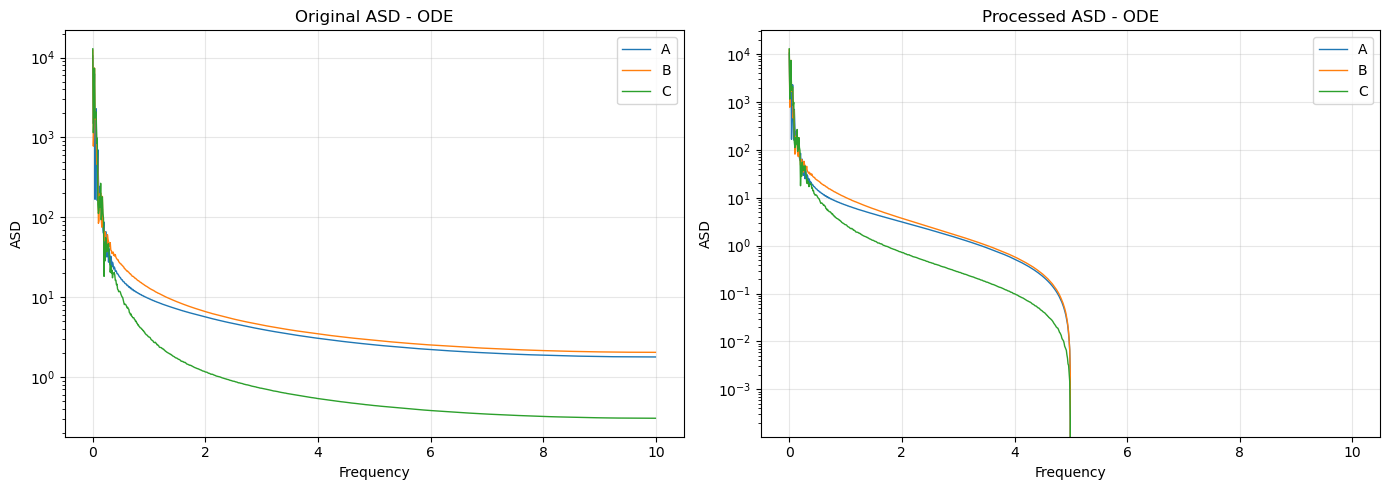

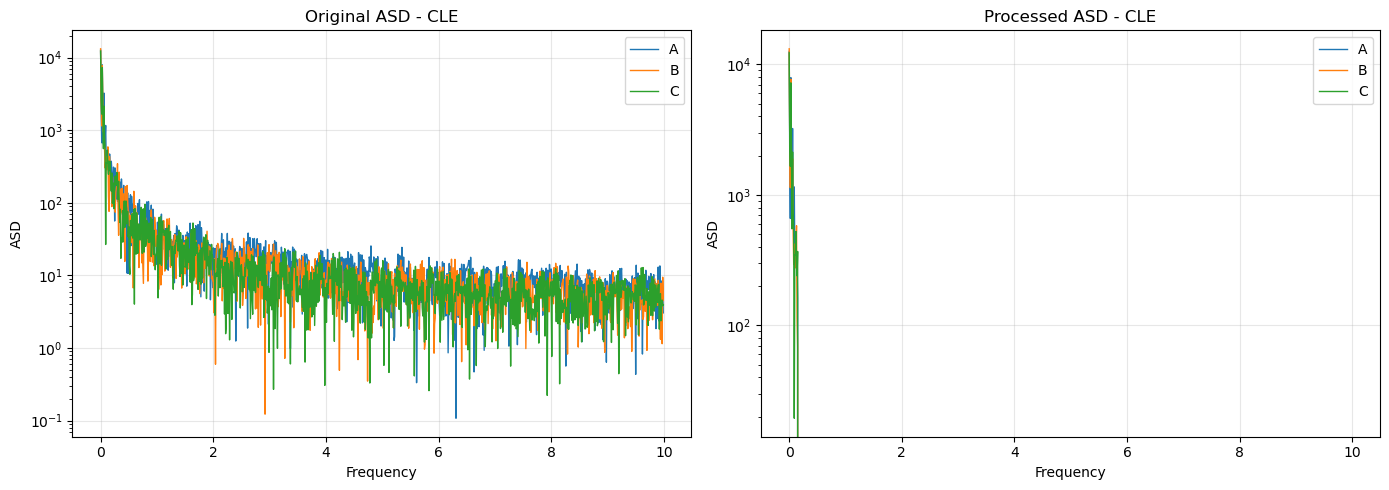

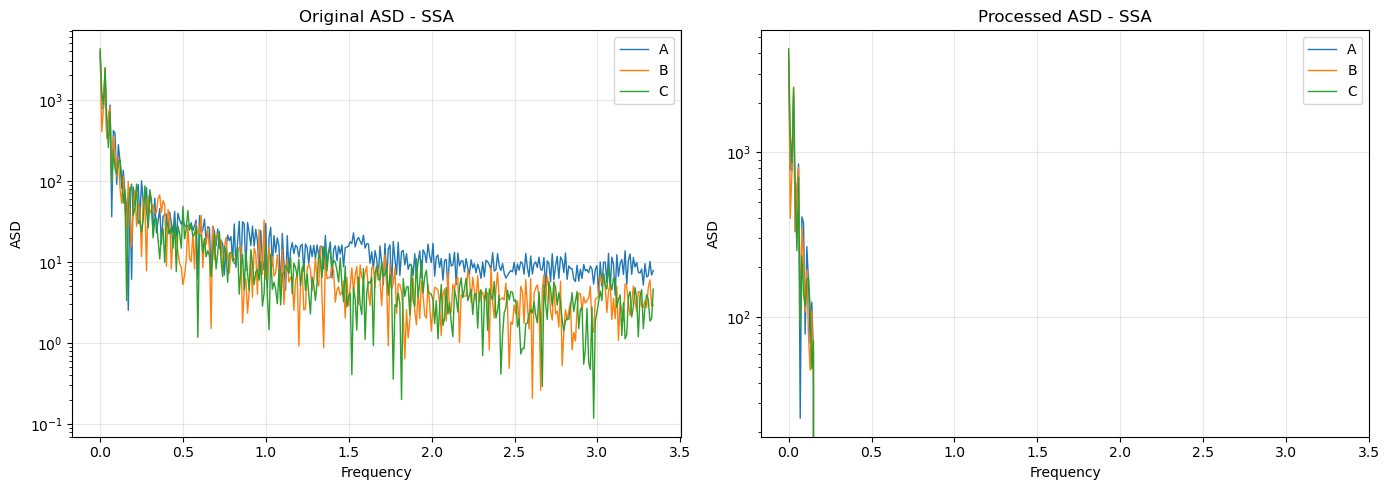

In [ ]:
# ── ASD Comparison: Before vs After Processing ────────────────────────────────
# Create 3 figures comparing original vs processed ASD for each simulation method

methods = [
    ("ODE", asd_original_ode, asd_processed_ode, freqs_ode),
    ("CLE", asd_original_cle, asd_processed_cle, freqs_cle),
    ("SSA", asd_original_ssa, asd_processed_ssa, freqs_ssa)
]

labels = ["A", "B", "C"]

for method_name, asd_original, asd_processed, freqs_method in methods:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), tight_layout=True)
    
    # Plot original ASD
    for i in range(3):
        ax1.semilogy(freqs_method, asd_original[:, i], lw=1.0, label=labels[i])
    ax1.set_xlabel("Frequency")
    ax1.set_ylabel("ASD")
    ax1.set_title(f"Original ASD - {method_name}")
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot processed ASD
    for i in range(3):
        ax2.semilogy(freqs_method, asd_processed[:, i], lw=1.0, label=labels[i])
    ax2.set_xlabel("Frequency")
    ax2.set_ylabel("ASD")
    ax2.set_title(f"Processed ASD - {method_name}")
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.show()

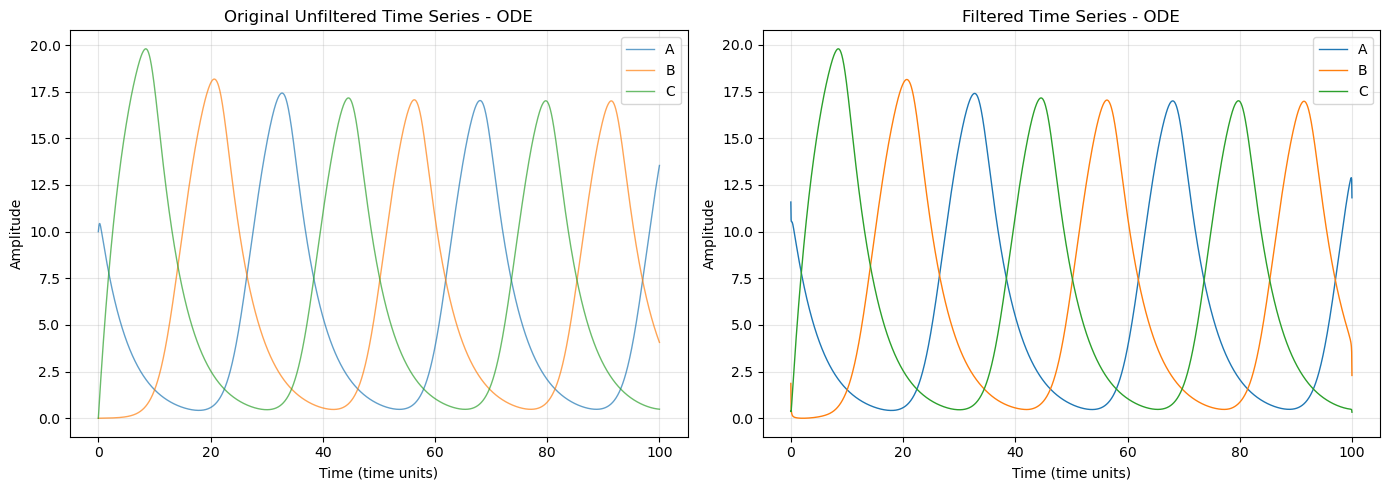

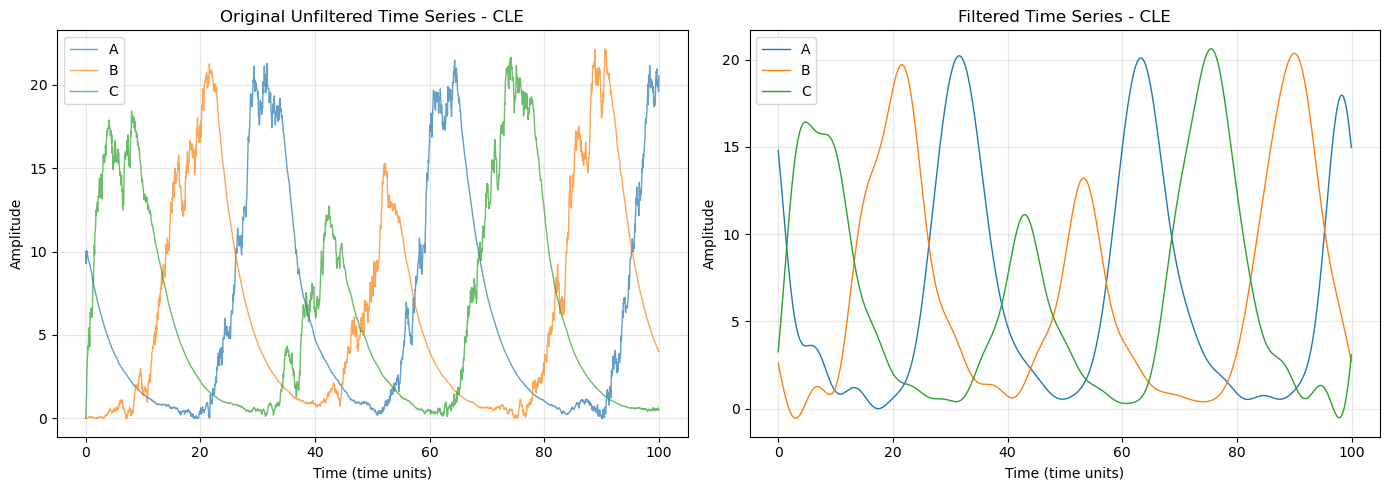

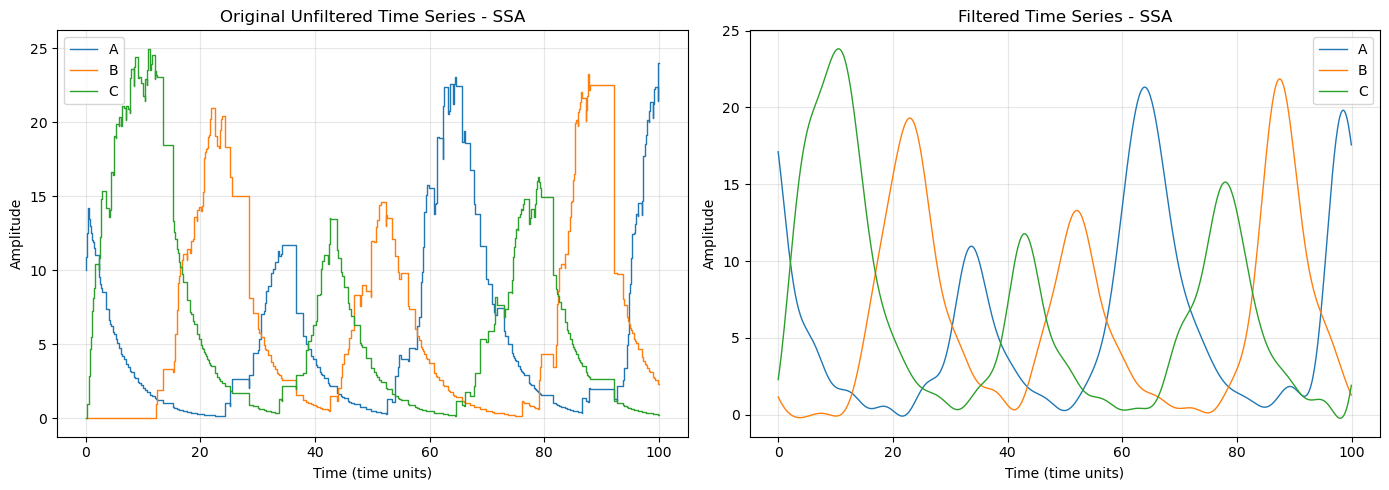

In [ ]:
# ── Time Series Comparison: Before vs After Filtering ──────────────────────────────────
# Create 3 figures comparing original (unfiltered) vs filtered time series for each simulation method

plt.rcParams['image.interpolation'] = 'none'

methods = [
    ("ODE", t_ode, y_ode, clean_signal_ode, t_uniform_ode),
    ("CLE", t_cle, y_cle, clean_signal_cle, t_uniform_cle),
    ("SSA", t_ssa, y_ssa, clean_signal_ssa, t_uniform_ssa)
]

labels = ["A", "B", "C"]

for method_name, t_original, y_original, y_filtered, t_filtered in methods:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), tight_layout=True)

    # For SSA, use step plot to show discrete jumps; for others use line plot
    if method_name == "SSA":
        for i in range(3):
            ax1.step(t_original, y_original[i, :], lw=1.0, label=labels[i], where="post")
    else:
        for i in range(3):
            ax1.plot(t_original, y_original[i, :], lw=1.0, label=labels[i], alpha=0.7)
    ax1.set_xlabel("Time (time units)")
    ax1.set_ylabel("Amplitude")
    ax1.set_title(f"Original Unfiltered Time Series - {method_name}")
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot filtered time series
    for i in range(3):
        ax2.plot(t_filtered, y_filtered[:, i], lw=1.0, label=labels[i])
    ax2.set_xlabel("Time (time units)")
    ax2.set_ylabel("Amplitude")
    ax2.set_title(f"Filtered Time Series - {method_name}")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

plt.show()

In [ ]:
import os
import pandas as pd

# Create output directory if it doesn't exist
output_dir = "./simulated_data"
os.makedirs(output_dir, exist_ok=True)

# Save both unfiltered and filtered time series for each simulation method
methods = [
    ("ODE", t_ode, y_ode, clean_signal_ode, t_uniform_ode),
    ("CLE", t_cle, y_cle, clean_signal_cle, t_uniform_cle),
    ("SSA", t_ssa, y_ssa, clean_signal_ssa, t_uniform_ssa)
]

for method_name, t_original, y_original, y_filtered, t_filtered in methods:
    # Save unfiltered version
    df_unfiltered = pd.DataFrame({
        'time': t_original,
        'A': y_original[0, :],
        'B': y_original[1, :],
        'C': y_original[2, :]
    })
    
    filename_unfiltered = os.path.join(output_dir, f"repressilator_sim_{method_name}_unfiltered.csv")
    df_unfiltered.to_csv(filename_unfiltered, index=False)
    print(f"Saved {filename_unfiltered}")
    
    # Save filtered version
    df_filtered = pd.DataFrame({
        'time': t_filtered,
        'A': y_filtered[:, 0],
        'B': y_filtered[:, 1],
        'C': y_filtered[:, 2]
    })
    
    filename_filtered = os.path.join(output_dir, f"repressilator_sim_{method_name}_filtered.csv")
    df_filtered.to_csv(filename_filtered, index=False)
    print(f"Saved {filename_filtered}")

print(f"\nAll simulations saved to {os.path.abspath(output_dir)}")

Saved ./simulated_data/repressilator_sim_ODE_unfiltered.csv
Saved ./simulated_data/repressilator_sim_ODE_filtered.csv
Saved ./simulated_data/repressilator_sim_CLE_unfiltered.csv
Saved ./simulated_data/repressilator_sim_CLE_filtered.csv
Saved ./simulated_data/repressilator_sim_SSA_unfiltered.csv
Saved ./simulated_data/repressilator_sim_SSA_filtered.csv

All simulations saved to /home/paytonco/biodynamics/systemID/SynBioDatasets/simulated_data
